In [1]:
import pandas as pd

In [2]:
df_purchase_behaviour = pd.read_csv("QVI_purchase_behaviour.csv")
print(df_purchase_behaviour.shape)
df_purchase_behaviour.head()

(72637, 3)


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [3]:
df_purchase_behaviour.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [4]:
df_transaction_data = pd.read_excel("QVI_transaction_data.xlsx")
print(df_transaction_data.shape)
df_transaction_data.head()

(264836, 8)


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
df_transaction_data["PROD_QTY"].describe()

count    264836.000000
mean          1.907309
std           0.643654
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

In [6]:
lower = round(df_transaction_data["PROD_QTY"].mean() - 3 * (df_transaction_data["PROD_QTY"].std()),2)
upper = round(df_transaction_data["PROD_QTY"].mean() + 3 * (df_transaction_data["PROD_QTY"].std()),2)
lower,upper

(np.float64(-0.02), np.float64(3.84))

In [7]:
df_transaction_data[(df_transaction_data.PROD_QTY < lower) | (df_transaction_data.PROD_QTY > upper)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
11,43332,8,8294,8221,114,Kettle Sensations Siracha Lime 150g,5,23.0
16,43330,20,20418,17413,94,Burger Rings 220g,4,9.2
31,43600,43,43227,40186,26,Pringles Sweet&Spcy BBQ 134g,4,14.8
56,43601,74,74336,73182,84,GrnWves Plus Btroot & Chilli Jam 180g,5,15.5
...,...,...,...,...,...,...,...,...
258721,43327,200,200248,199694,3,Kettle Sensations Camembert & Fig 150g,4,18.4
258726,43332,203,203253,203360,28,Thins Potato Chips Hot & Spicy 175g,5,16.5
258729,43601,208,208205,207318,37,Smiths Thinly Swt Chli&S/Cream175G,5,15.0
258759,43599,238,238169,242560,44,Thins Chips Light& Tangy 175g,4,13.2


In [8]:
df_transaction_data[(df_transaction_data["PROD_QTY"] > 50)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [11]:
df_transaction_data = df_transaction_data[df_transaction_data["PROD_QTY"] < 50]

In [12]:
df_transaction_data.shape

(264834, 8)

In [13]:
df_combine = pd.merge(df_purchase_behaviour , df_transaction_data , on = "LYLTY_CARD_NBR")

In [14]:
df_combine.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,1000,YOUNG SINGLES/COUPLES,Premium,43390,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,1002,YOUNG SINGLES/COUPLES,Mainstream,43359,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7
2,1003,YOUNG FAMILIES,Budget,43531,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6
3,1003,YOUNG FAMILIES,Budget,43532,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0
4,1004,OLDER SINGLES/COUPLES,Mainstream,43406,1,5,96,WW Original Stacked Chips 160g,1,1.9


<Axes: xlabel='LIFESTAGE,PREMIUM_CUSTOMER'>

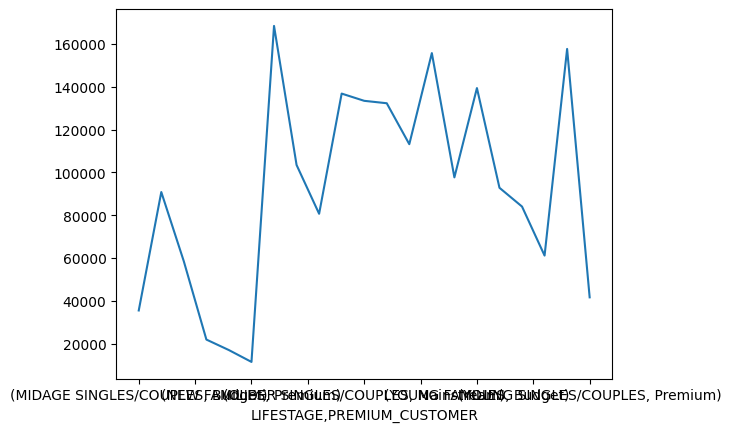

In [25]:
(df_combine.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"].sum()).plot()


In [20]:
df_combine.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique()

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Budget              1504
                        Mainstream          3340
                        Premium             2431
NEW FAMILIES            Budget              1112
                        Mainstream           849
                        Premium              588
OLDER FAMILIES          Budget              4675
                        Mainstream          2831
                        Premium             2273
OLDER SINGLES/COUPLES   Budget              4929
                        Mainstream          4930
                        Premium             4750
RETIREES                Budget              4454
                        Mainstream          6479
                        Premium             3872
YOUNG FAMILIES          Budget              4017
                        Mainstream          2728
                        Premium             2433
YOUNG SINGLES/COUPLES   Budget              3779
                        Main

In [21]:
df_combine.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["PROD_QTY"].mean()

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Budget              1.891633
                        Mainstream          1.911656
                        Premium             1.889727
NEW FAMILIES            Budget              1.853910
                        Mainstream          1.857634
                        Premium             1.860919
OLDER FAMILIES          Budget              1.945812
                        Mainstream          1.948610
                        Premium             1.945576
OLDER SINGLES/COUPLES   Budget              1.913403
                        Mainstream          1.910525
                        Premium             1.914273
RETIREES                Budget              1.892244
                        Mainstream          1.887543
                        Premium             1.900122
YOUNG FAMILIES          Budget              1.940749
                        Mainstream          1.940342
                        Premium             1.937732
YOUNG

In [29]:
df_combine.groupby("PROD_NAME")["TOT_SALES"].sum().sort_values(ascending=False).head(10)

PROD_NAME
Dorito Corn Chp     Supreme 380g            39052.0
Smiths Crnkle Chip  Orgnl Big Bag 380g      36367.6
Smiths Crinkle Chips Salt & Vinegar 330g    34804.2
Kettle Mozzarella   Basil & Pesto 175g      34457.4
Smiths Crinkle      Original 330g           34302.6
Cheezels Cheese 330g                        34296.9
Doritos Cheese      Supreme 330g            33390.6
Kettle Sweet Chilli And Sour Cream 175g     33031.8
Kettle Original 175g                        32740.2
Kettle Sea Salt     And Vinegar 175g        32589.0
Name: TOT_SALES, dtype: float64

In [38]:
df_combine["PROD_NAME"].value_counts()

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
                                            ... 
RRD Pc Sea Salt     165g                    1431
Woolworths Medium   Salsa 300g              1430
NCC Sour Cream &    Garden Chives 175g      1419
French Fries Potato Chips 175g              1418
WW Crinkle Cut      Original 175g           1410
Name: count, Length: 114, dtype: int64

In [1]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

os.makedirs('charts', exist_ok=True)

# ── CONSISTENT COLOUR PALETTE ────────────────────────────────────────────────
NAVY  = '#1B3A5C'   # dark navy  — titles, axes
BLUE  = '#2E86C1'   # mid blue   — main bars / series
GOLD  = '#F39C12'   # gold       — top performer / highlight
GREEN = '#1E8449'   # green      — positive trial result
LGREY = '#F4F6F8'   # light grey — background panels
MGREY = '#95A5A6'   # mid grey   — axis labels

# Store colours — MUST stay the same across all trial charts
S77_COLOR = BLUE
S86_COLOR = NAVY
S88_COLOR = GOLD

def style_ax(ax):
    """Apply consistent clean styling to any axis."""
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#D5D8DC')
    ax.tick_params(colors='#555555', labelsize=9)
    ax.yaxis.grid(True, color='#EBF0F5', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# ════════════════════════════════════════════════════════════════════════════
# CHART 1 — Total Sales by Customer Segment (Task 1)
# ════════════════════════════════════════════════════════════════════════════
labels = [
    'Older Singles/Couples\n(Mainstream)',
    'Older Families\n(Mainstream)',
    'Young Families\n(Budget)',
    'Older Singles/Couples\n(Budget)',
    'Young Singles/Couples\n(Mainstream)',
    'Older Families\n(Budget)',        # ← top performer: GOLD
]
values = [133.4, 130.1, 139.3, 136.8, 157.6, 168.4]
bar_colors = [BLUE, BLUE, BLUE, BLUE, BLUE, GOLD]

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')
style_ax(ax)

bars = ax.barh(labels, values, color=bar_colors, height=0.55, zorder=3)
for bar, v in zip(bars, values):
    ax.text(v + 1.5, bar.get_y() + bar.get_height() / 2,
            f'£{v:.0f}K', va='center', ha='left',
            fontsize=9.5, fontweight='bold', color=NAVY)

ax.set_xlabel('Total Sales (£000s)', fontsize=10, color=MGREY, labelpad=8)
ax.set_title('Total Sales by Customer Segment', fontsize=13, fontweight='bold',
             color=NAVY, pad=14)
ax.set_xlim(0, 195)

legend_handles = [
    mpatches.Patch(color=GOLD, label='Top segment — Older Families (Budget)'),
    mpatches.Patch(color=BLUE, label='Other top segments'),
]
ax.legend(handles=legend_handles, fontsize=8.5, loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.savefig('charts/chart1_total_sales.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.close()
print("Chart 1 saved: charts/chart1_total_sales.png")


# ════════════════════════════════════════════════════════════════════════════
# CHART 2 — Unique Customers by Segment (Task 1)
# ════════════════════════════════════════════════════════════════════════════
labels2 = [
    'Retirees\n(Mainstream)',
    'Older Singles/Couples\n(Budget)',
    'Older Singles/Couples\n(Mainstream)',
    'Young Families\n(Mainstream)',
    'Retirees\n(Budget)',
    'Young Singles/Couples\n(Mainstream)',   # ← largest: GREEN
]
values2 = [3220, 4929, 4930, 3541, 3115, 8088]
bar_colors2 = [BLUE, BLUE, BLUE, BLUE, BLUE, GREEN]

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')
style_ax(ax)

bars2 = ax.barh(labels2, values2, color=bar_colors2, height=0.55, zorder=3)
for bar, v in zip(bars2, values2):
    ax.text(v + 80, bar.get_y() + bar.get_height() / 2,
            f'{v:,}', va='center', ha='left',
            fontsize=9.5, fontweight='bold', color=NAVY)

ax.set_xlabel('Unique Customers', fontsize=10, color=MGREY, labelpad=8)
ax.set_title('Unique Customers by Segment', fontsize=13, fontweight='bold',
             color=NAVY, pad=14)
ax.set_xlim(0, 10000)

legend_handles2 = [
    mpatches.Patch(color=GREEN, label='Largest segment — Young Singles/Couples (Mainstream)'),
    mpatches.Patch(color=BLUE,  label='Other top segments'),
]
ax.legend(handles=legend_handles2, fontsize=8.5, loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.savefig('charts/chart2_customers.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.close()
print("Chart 2 saved: charts/chart2_customers.png")


# ════════════════════════════════════════════════════════════════════════════
# CHART 3 — Average Spend per Customer (Task 1)
# ════════════════════════════════════════════════════════════════════════════
labels3 = [
    'Young Singles/\nCouples (MS)',
    'Retirees\n(MS)',
    'Older Singles/\nCouples (MS)',
    'Older Singles/\nCouples (Bdg)',
    'Young Families\n(Bdg)',
    'Older Families\n(Bdg)',      # ← highest spend: GOLD
]
values3 = [19.5, 24.0, 27.1, 27.7, 34.7, 36.0]
bar_colors3 = [BLUE, BLUE, BLUE, BLUE, BLUE, GOLD]

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')
style_ax(ax)

bars3 = ax.bar(labels3, values3, color=bar_colors3, width=0.55, zorder=3)
for bar, v in zip(bars3, values3):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5,
            f'£{v:.1f}', ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color=NAVY)

ax.set_ylabel('Avg Annual Spend per Customer (£)', fontsize=10, color=MGREY, labelpad=8)
ax.set_title('Average Spend per Customer by Segment', fontsize=13, fontweight='bold',
             color=NAVY, pad=14)
ax.set_ylim(0, 44)
ax.tick_params(axis='x', labelsize=8.5)

legend_handles3 = [
    mpatches.Patch(color=GOLD, label='Highest spend — Older Families (Budget): £36'),
    mpatches.Patch(color=BLUE, label='Other segments'),
]
ax.legend(handles=legend_handles3, fontsize=8.5, framealpha=0.8)

plt.tight_layout()
plt.savefig('charts/chart3_avg_spend.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.close()
print("Chart 3 saved: charts/chart3_avg_spend.png")


# ════════════════════════════════════════════════════════════════════════════
# CHART 4 — Sales Difference vs Control Store (Task 2)
# ════════════════════════════════════════════════════════════════════════════
# Store colours consistent across ALL trial charts
store_labels = ['Store 77\nvs Control 31', 'Store 86\nvs Control 31', 'Store 88\nvs Control 206']
month1_sales = [219.2,  908.6, 1307.0]
month2_sales = [236.5,  909.2, 1434.8]
month1_labels = ['Sep 2018', 'Sep 2018', 'Jul 2018']
month2_labels = ['Nov 2018', 'Nov 2018', 'Apr 2019']

x = np.arange(len(store_labels))
w = 0.32

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')
style_ax(ax)

b1 = ax.bar(x - w/2, month1_sales, w, color=[S77_COLOR, S86_COLOR, S88_COLOR],
            zorder=3, label='Month 1', alpha=0.85)
b2 = ax.bar(x + w/2, month2_sales, w, color=[S77_COLOR, S86_COLOR, S88_COLOR],
            zorder=3, label='Month 2', alpha=1.0, edgecolor='white', linewidth=1.5,
            hatch='//')

for bar, v in zip(b1, month1_sales):
    ax.text(bar.get_x() + bar.get_width()/2, v + 18, f'£{v:.0f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=NAVY)
for bar, v in zip(b2, month2_sales):
    ax.text(bar.get_x() + bar.get_width()/2, v + 18, f'£{v:.0f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=NAVY)

ax.set_xticks(x)
ax.set_xticklabels(store_labels, fontsize=9.5)
ax.set_ylabel('Sales Difference vs Control (£)', fontsize=10, color=MGREY, labelpad=8)
ax.set_title('Trial vs Control — Sales Difference by Store', fontsize=13,
             fontweight='bold', color=NAVY, pad=14)

legend_handles4 = [
    mpatches.Patch(color=S77_COLOR, label='Store 77 (Control: 31)'),
    mpatches.Patch(color=S86_COLOR, label='Store 86 (Control: 31)'),
    mpatches.Patch(color=S88_COLOR, label='Store 88 (Control: 206)'),
    mpatches.Patch(facecolor='white', edgecolor='grey', hatch='//', label='Month 2'),
]
ax.legend(handles=legend_handles4, fontsize=8.5, framealpha=0.8, ncol=2)

plt.tight_layout()
plt.savefig('charts/chart4_sales_diff.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.close()
print("Chart 4 saved: charts/chart4_sales_diff.png")


# ════════════════════════════════════════════════════════════════════════════
# CHART 5 — Customer Count Difference vs Control (Task 2)
# ════════════════════════════════════════════════════════════════════════════
month1_custs = [41, 102, 128]
month2_custs = [40,  99, 127]

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')
style_ax(ax)

b1 = ax.bar(x - w/2, month1_custs, w, color=[S77_COLOR, S86_COLOR, S88_COLOR],
            zorder=3, alpha=0.85)
b2 = ax.bar(x + w/2, month2_custs, w, color=[S77_COLOR, S86_COLOR, S88_COLOR],
            zorder=3, alpha=1.0, edgecolor='white', linewidth=1.5, hatch='//')

for bar, v in zip(b1, month1_custs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, str(v),
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=NAVY)
for bar, v in zip(b2, month2_custs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, str(v),
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=NAVY)

ax.set_xticks(x)
ax.set_xticklabels(store_labels, fontsize=9.5)
ax.set_ylabel('Customer Count Difference vs Control', fontsize=10, color=MGREY, labelpad=8)
ax.set_title('Trial vs Control — Customer Count Difference by Store', fontsize=13,
             fontweight='bold', color=NAVY, pad=14)

ax.legend(handles=legend_handles4, fontsize=8.5, framealpha=0.8, ncol=2)

plt.tight_layout()
plt.savefig('charts/chart5_cust_diff.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.close()
print("Chart 5 saved: charts/chart5_cust_diff.png")


# ════════════════════════════════════════════════════════════════════════════
# CHART 6 — Transactions per Customer Difference (Task 2)
# ════════════════════════════════════════════════════════════════════════════
month1_txn = [0.048, 0.243, 0.186]
month2_txn = [0.073, 0.250, 0.266]

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')
style_ax(ax)

b1 = ax.bar(x - w/2, month1_txn, w, color=[S77_COLOR, S86_COLOR, S88_COLOR],
            zorder=3, alpha=0.85)
b2 = ax.bar(x + w/2, month2_txn, w, color=[S77_COLOR, S86_COLOR, S88_COLOR],
            zorder=3, alpha=1.0, edgecolor='white', linewidth=1.5, hatch='//')

for bar, v in zip(b1, month1_txn):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.004, f'{v:.3f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=NAVY)
for bar, v in zip(b2, month2_txn):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.004, f'{v:.3f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=NAVY)

ax.set_xticks(x)
ax.set_xticklabels(store_labels, fontsize=9.5)
ax.set_ylabel('Txn per Customer Difference vs Control', fontsize=10, color=MGREY, labelpad=8)
ax.set_title('Trial vs Control — Transactions per Customer Difference', fontsize=13,
             fontweight='bold', color=NAVY, pad=14)

ax.legend(handles=legend_handles4, fontsize=8.5, framealpha=0.8, ncol=2)

plt.tight_layout()
plt.savefig('charts/chart6_txn_diff.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.close()
print("Chart 6 saved: charts/chart6_txn_diff.png")


print("\nAll 6 charts saved to the 'charts/' folder!")
print("Colours used consistently:")
print(f"  Blue  {BLUE}  — main bars / Store 77")
print(f"  Navy  {NAVY}  — Store 86")
print(f"  Gold  {GOLD}  — top performer highlight / Store 88")
print(f"  Green {GREEN}  — largest customer segment")

Chart 1 saved: charts/chart1_total_sales.png
Chart 2 saved: charts/chart2_customers.png
Chart 3 saved: charts/chart3_avg_spend.png
Chart 4 saved: charts/chart4_sales_diff.png
Chart 5 saved: charts/chart5_cust_diff.png
Chart 6 saved: charts/chart6_txn_diff.png

All 6 charts saved to the 'charts/' folder!
Colours used consistently:
  Blue  #2E86C1  — main bars / Store 77
  Navy  #1B3A5C  — Store 86
  Gold  #F39C12  — top performer highlight / Store 88
  Green #1E8449  — largest customer segment
